# Performance Benchmarking for VibeSpin

This notebook measures the runtime behaviour of six simulation models across two update schemes and five lattice sizes. The models are: Ising (discrete $\pm 1$ spins), XY (continuous 2D unit vectors), Clock Continuous ($q=6$, XY dynamics plus $q$-fold anisotropy), and Clock Discrete ($q=6$, integer state indices). Each runs with both checkerboard and random-sequential Metropolis updates, for eight curves in total.

Analysis costs divide into two tiers by when in a measurement run the cost is paid. **Per-step observables** — magnetization $M$ and energy $E$ — are evaluated at every MC sweep inside the measurement window, so their per-call cost multiplies with the window length. **Post-hoc observables** — susceptibility $\chi = N\,\mathrm{Var}(M)/T$, specific heat $C_v = N\,\mathrm{Var}(E)/T^2$, the spatial correlation function $G(r)$, and the autocorrelation time $\tau_\mathrm{int}$ — are computed once after the window closes from the stored M and E series or from a spin-field snapshot. They carry no per-step cost. Sections below treat each tier separately: the thermodynamic cost section covers per-step M and E collection; G(r) and $\tau_\mathrm{int}$ have dedicated sections since their scaling and use differ from per-step collection.

Because Numba JIT compiles each kernel on first call, reported times are only stable after warm-up. The `measure_performance` helper runs three warm-up steps before starting any clock. For reproducible numbers, execute all cells once to compile, then re-run the benchmark cell.

---
### Scientific References

For physical models and algorithms:
- L. Onsager, "Crystal Statistics. I. A Two-Dimensional Model with an Order-Disorder Transition," Physical Review, vol. 65, no. 3-4, pp. 117–149, 1944. ([APS Open Access](https://journals.aps.org/pr/abstract/10.1103/PhysRev.65.117))
- J. M. Kosterlitz and D. J. Thouless, "Ordering, metastability and phase transitions in two-dimensional systems," Journal of Physics C: Solid State Physics, vol. 6, no. 7, pp. 1181–1203, 1973. ([IOP Open Access](https://iopscience.iop.org/article/10.1088/0022-3719/6/7/010))
- J. Lapilli, P. Pfeifer, and C. Wexler, "Universality away from critical points in two-dimensional phase transitions," Physical Review Letters, vol. 96, no. 14, 140603, 2006. ([APS Open Access](https://journals.aps.org/prl/abstract/10.1103/PhysRevLett.96.140603))
- W. K. Hastings, "Monte Carlo sampling methods using Markov chains and their applications," Biometrika, vol. 57, no. 1, pp. 97–109, 1970. ([Oxford Academic Open Access](https://academic.oup.com/biomet/article/57/1/97/252073))
- Numba JIT and parallelization: https://numba.readthedocs.io/en/stable/user/parallel.html
- [Ising model on Wikipedia](https://en.wikipedia.org/wiki/Ising_model)
- [XY model on Wikipedia](https://en.wikipedia.org/wiki/XY_model)
- [Clock model on Wikipedia](https://en.wikipedia.org/wiki/Potts_model#Vector_Potts_model)
- [Metropolis–Hastings algorithm on Wikipedia](https://en.wikipedia.org/wiki/Metropolis%E2%80%93Hastings_algorithm)


In [18]:
import os
import time

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress
from tqdm.auto import tqdm

from models.clock_model import ClockSimulation, DiscreteClockSimulation
from models.ising_model import IsingSimulation
from models.xy_model import XYSimulation
from utils.physics_helpers import calculate_autocorr

%matplotlib inline
plt.style.use('seaborn-v0_8-muted')
plt.rcParams['figure.dpi'] = 100

## Setup

The first code cell below defines global constants: a fixed seed (`SEED = 42`), the number of iterations for analysis timing (`ANALYSIS_ITERS = 50`), and a sweep count per lattice size (`N_SWEEPS_MAP`). Larger lattices get fewer timed sweeps to keep total runtime under a few minutes while preserving the scaling trend across five decades of $N$. It also sets consistent plot colours, markers, and line styles for all eight model variants.

The second code cell defines `measure_performance`. It accepts a live simulation instance and runs three silent warm-up steps to trigger JIT compilation for sweep, thermodynamic, and $G(r)$ kernels before any timing begins. (Compiling the $G(r)$ kernel at this stage means the dedicated $G(r)$ section later gets stable timings without its own warm-up pass.) Sweep throughput is then measured over the full `sweeps` count. Thermodynamic collection cost is averaged over `analysis_iters` independent calls to `_get_energy()` and `_get_magnetization()`, which represent the per-step overhead incurred inside a measurement window.

In [19]:
# --- Benchmark configuration -------------------------------------------------
SEED = 42
ANALYSIS_ITERS = 50
N_SWEEPS_MAP = {32: 200, 64: 200, 128: 200, 256: 50, 512: 50}

_model_names = [
    'Ising (Checkerboard)',
    'Ising (Random)',
    'XY (Checkerboard)',
    'XY (Random)',
    'Clock Continuous (Checkerboard)',
    'Clock Continuous (Random)',
    'Clock Discrete (Checkerboard)',
    'Clock Discrete (Random)',
]

_palette = [c['color'] for c in plt.rcParams['axes.prop_cycle']]
MODEL_COLORS = {name: _palette[i % len(_palette)] for i, name in enumerate(_model_names)}
MODEL_MARKERS = {
    'Ising (Checkerboard)': 'o',
    'Ising (Random)': 's',
    'XY (Checkerboard)': '^',
    'XY (Random)': 'D',
    'Clock Continuous (Checkerboard)': 'v',
    'Clock Continuous (Random)': 'P',
    'Clock Discrete (Checkerboard)': 'X',
    'Clock Discrete (Random)': '*',
}
MODEL_LS = {name: '-' if 'Checkerboard' in name else '--' for name in _model_names}

In [20]:
def measure_performance(sim, sweeps=100, analysis_iters=50):
    """Measure sweeps/sec and per-step thermodynamic collection cost.

    PER-STEP observables (timed here):
        _get_magnetization(), _get_energy()
        Called at every sweep inside a measurement window; cost multiplies
        with window length and depends on model and lattice size.

    POST-HOC observables (NOT timed here, zero per-step cost):
        susceptibility  chi = N * Var(M) / T
        specific heat   C_v = N * Var(E) / T^2
        Both are derived once from the accumulated M and E arrays after the
        window closes -- a single variance pass independent of N and model.
        G(r) and tau_int fall into the same category and have dedicated sections.
    """
    # Warm-up: triggers JIT compilation for sweep, thermo, and G(r) kernels.
    # G(r) is compiled here so the dedicated G(r) section gets stable timings later.
    for _ in range(3):
        sim.step()
        sim._get_energy()
        sim._get_magnetization()
        sim._calculate_correlation_function()

    # 1. Sweep speed (Throughput)
    start = time.perf_counter()
    for _ in range(sweeps):
        sim.step()
    sweep_duration = time.perf_counter() - start
    sps = sweeps / sweep_duration

    # 2. Per-step thermodynamic collection: M and E.
    # chi and C_v are NOT measured here -- they derive post-hoc from Var(M) and
    # Var(E) of the collected series and add no per-step cost to the run.
    start = time.perf_counter()
    for _ in range(analysis_iters):
        sim._get_energy()
        sim._get_magnetization()
    thermo_ms = (time.perf_counter() - start) / analysis_iters * 1000

    return {'sps': sps, 'thermo_ms': thermo_ms}

## Throughput Benchmark

The benchmark runs all eight model variants at lattice sizes $L \in \{32, 64, 128, 256, 512\}$. Temperatures are fixed at physically relevant points: $T = 2.269$ for Ising (within 0.1% of the known 2D critical temperature $T_c \approx 2.2692$), $T = 0.89$ for XY (near the Berezinskii\u2013Kosterlitz\u2013Thouless transition at $T_{\text{BKT}} \approx 0.89$), and $T = 0.5$ for both $q = 6$ clock variants (well inside the ordered phase). Choosing these points ensures realistic acceptance rates rather than trivial cases where nearly every or nearly no proposal is accepted.

Results are stored in `results[model_name][L]` as a dict with keys `sps` (sweeps per second) and `thermo_ms` (per-step thermodynamic collection cost in milliseconds). All subsequent plots up to the $G(r)$ section read from this structure.

In [21]:
sizes = [32, 64, 128, 256, 512]
model_configs = [
    (
        'Ising (Checkerboard)',
        lambda L: IsingSimulation(size=L, temp=2.269, update='checkerboard', seed=SEED),
    ),
    ('Ising (Random)', lambda L: IsingSimulation(size=L, temp=2.269, update='random', seed=SEED)),
    (
        'XY (Checkerboard)',
        lambda L: XYSimulation(size=L, temp=0.89, update='checkerboard', seed=SEED),
    ),
    ('XY (Random)', lambda L: XYSimulation(size=L, temp=0.89, update='random', seed=SEED)),
    (
        'Clock Continuous (Checkerboard)',
        lambda L: ClockSimulation(size=L, temp=0.5, q=6, A=0.1, update='checkerboard', seed=SEED),
    ),
    (
        'Clock Continuous (Random)',
        lambda L: ClockSimulation(size=L, temp=0.5, q=6, A=0.1, update='random', seed=SEED),
    ),
    (
        'Clock Discrete (Checkerboard)',
        lambda L: DiscreteClockSimulation(size=L, temp=0.5, q=6, update='checkerboard', seed=SEED),
    ),
    (
        'Clock Discrete (Random)',
        lambda L: DiscreteClockSimulation(size=L, temp=0.5, q=6, update='random', seed=SEED),
    ),
]

_NPZ_PATH = '../results/benchmarks/scaling_benchmark.npz'
_NPZ_METRICS = ('sps', 'thermo_ms', 'corr_ms', 'vort_ms', 'vden_ms', 'heli_ms')

if os.path.exists(_NPZ_PATH):
    _data = np.load(_NPZ_PATH, allow_pickle=True)
    _npz_names = [str(n) for n in _data['model_names']]
    _npz_sizes = [int(s) for s in _data['sizes']]
    results = {
        name: {
            L: {m: float(_data[m][i, j]) for m in _NPZ_METRICS}
            for j, L in enumerate(_npz_sizes)
        }
        for i, name in enumerate(_npz_names)
    }
    sizes = _npz_sizes
    _loaded_from_npz = True
    print(f'Loaded from {_NPZ_PATH}')
    print(f'  Models : {_npz_names}')
    print(f'  Sizes  : {_npz_sizes}')
else:
    results = {name: {} for name, _ in model_configs}
    for L in tqdm(sizes, desc='Lattice Sizes'):
        for name, constructor in model_configs:
            sim = constructor(L)
            n_sweeps = N_SWEEPS_MAP.get(L, 200 if L <= 128 else 50)
            metrics = measure_performance(sim, sweeps=n_sweeps, analysis_iters=ANALYSIS_ITERS)
            results[name][L] = metrics
    _loaded_from_npz = False
    print('Benchmark complete. Run scripts/benchmarks/throughput.py to cache results for re-use.')

Lattice Sizes:   0%|          | 0/5 [00:00<?, ?it/s]

Benchmark complete. Run scripts/benchmarks/throughput.py to cache results for re-use.


## Throughput: Log-Log Plot

The plot below shows sweeps per second on a log-log scale against system size $N = L^2$. One sweep corresponds to a full lattice pass: $N$ randomly chosen flip attempts for random-sequential updates, or two sublattice passes for checkerboard. On a log-log scale, a line with slope $-1$ would indicate constant cost per spin (ideal $O(N)$ scaling).

The Ising model occupies the top of the chart. Its binary spin space limits each Metropolis evaluation to two pre-computed Boltzmann factors ($e^{-4J\beta}$ and $e^{-8J\beta}$), with no per-site transcendental functions. XY and the continuous clock both compute `arctan2` and trigonometric evaluations per proposal, which is visible as a substantial throughput drop. The discrete clock reaches for the same Hamiltonian as the continuous clock but evaluates $\Delta E$ via a length-$q$ cosine table, recovering much of the Ising advantage.

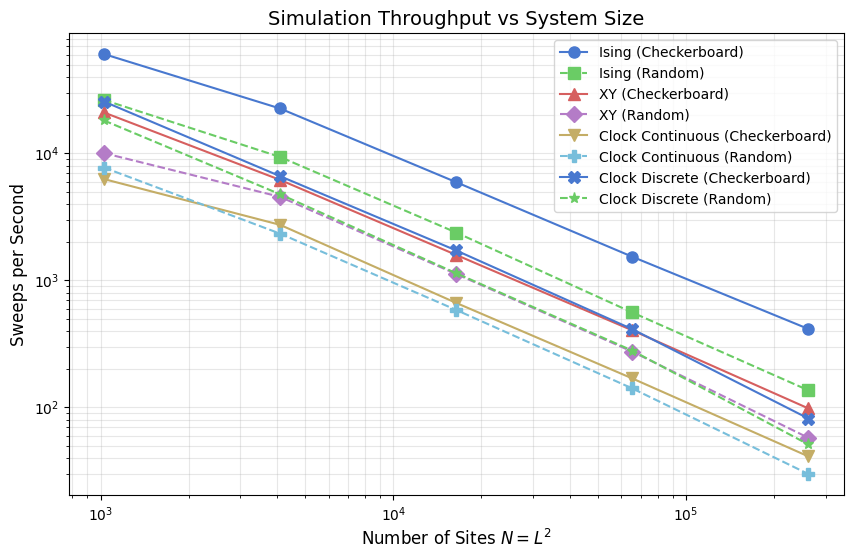

In [22]:
plt.figure(figsize=(10, 6))
for name in results:
    L_vals = sorted(results[name].keys())
    N_vals = [L*L for L in L_vals]
    sps_vals = [results[name][L]['sps'] for L in L_vals]
    plt.loglog(
        N_vals, sps_vals,
        marker=MODEL_MARKERS[name], linestyle=MODEL_LS[name], color=MODEL_COLORS[name],
        label=name, markersize=8,
    )

plt.title('Simulation Throughput vs System Size', fontsize=14)
plt.xlabel('Number of Sites $N = L^2$', fontsize=12)
plt.ylabel('Sweeps per Second', fontsize=12)
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.legend()
plt.show()

## Thermodynamic Analysis Cost: Per-Step Collection

A measurement run has two distinct cost phases. During the window, `_get_magnetization()` and `_get_energy()` are called at every sweep to build the time series $M(t)$ and $E(t)$. This is the only thermodynamic cost paid per step, and it scales with window length: a $W = 10{,}000$ sweep window means $10{,}000$ calls to each. After the window closes, susceptibility and specific heat are derived from the accumulated arrays with a single variance pass:

$$\chi = \frac{N}{T}\bigl(\langle M^2 \rangle - \langle M \rangle^2\bigr), \qquad C_v = \frac{N}{T^2}\bigl(\langle E^2 \rangle - \langle E \rangle^2\bigr)$$

This post-hoc step costs a fixed amount regardless of $N$ or model — it does not appear in the per-step timings plotted here. $G(r)$ and $\tau_\mathrm{int}$ are likewise post-hoc: $G(r)$ operates on a single spin-field snapshot, and $\tau_\mathrm{int}$ is extracted from the full $M(t)$ series; both receive dedicated sections further below.

The plot shows per-call timing of `_get_energy()` + `_get_magnetization()` vs system size $N$. The cost difference between models reflects how each computes instantaneous observables from its spin representation. Ising sums a scalar $\pm 1$ array in one pass. XY and the clock models project per-site vector components or query lookup tables, roughly doubling the Ising cost. All models scale $\propto N$, consistent with a single linear traversal per call.

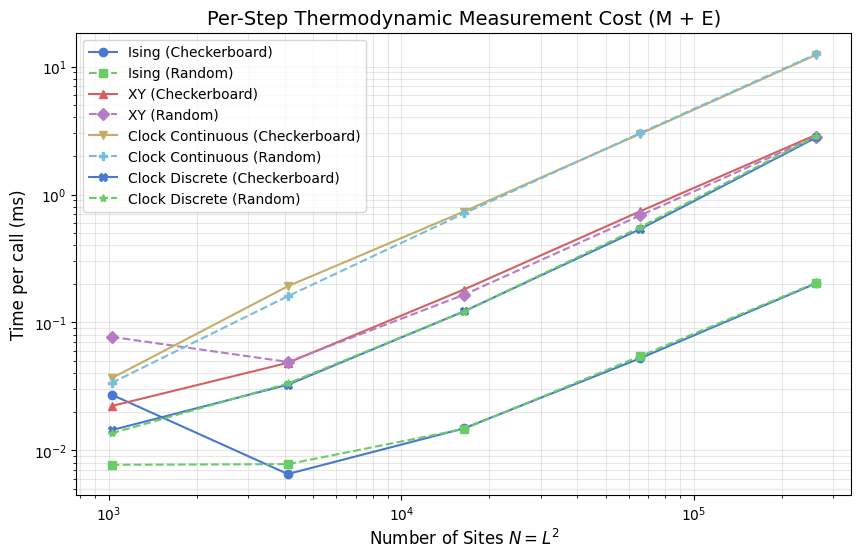

In [23]:
plt.figure(figsize=(10, 6))

for name in results:
    L_vals = sorted(results[name].keys())
    N_vals = [L*L for L in L_vals]
    thermo_vals = [results[name][L]['thermo_ms'] for L in L_vals]
    plt.loglog(
        N_vals, thermo_vals,
        marker=MODEL_MARKERS[name], linestyle=MODEL_LS[name], color=MODEL_COLORS[name],
        label=name,
    )

plt.title('Per-Step Thermodynamic Measurement Cost (M + E)', fontsize=14)
plt.xlabel('Number of Sites $N = L^2$', fontsize=12)
plt.ylabel('Time per call (ms)', fontsize=12)
plt.grid(True, which='both', alpha=0.3)
plt.legend()
plt.show()

## Thermodynamic Overhead Ratio

This plot shows (per-step M+E collection time) / (sweep time) — the fraction of each sweep's budget consumed by recording the two per-step observables. The ratio only covers the quantities that must be collected at every step; post-hoc observables (χ, C_v, G(r), τ_int) are paid once per window regardless of its length and do not contribute to this ratio.

When the ratio exceeds 1.0 (dashed reference), calling `_get_energy()` and `_get_magnetization()` at every sweep adds more overhead than the sweep itself. Fast-sweeping models such as Ising approach or exceed that crossover at large $L$ because their sweep time is suppressed by integer arithmetic while the observable evaluation still scans the full $N$-site array. Slow-sweeping models such as the continuous clock stay well below 1.0: each sweep is already expensive relative to the measurement pass. The discrete clock sits between the two, in line with its intermediate sweep cost.

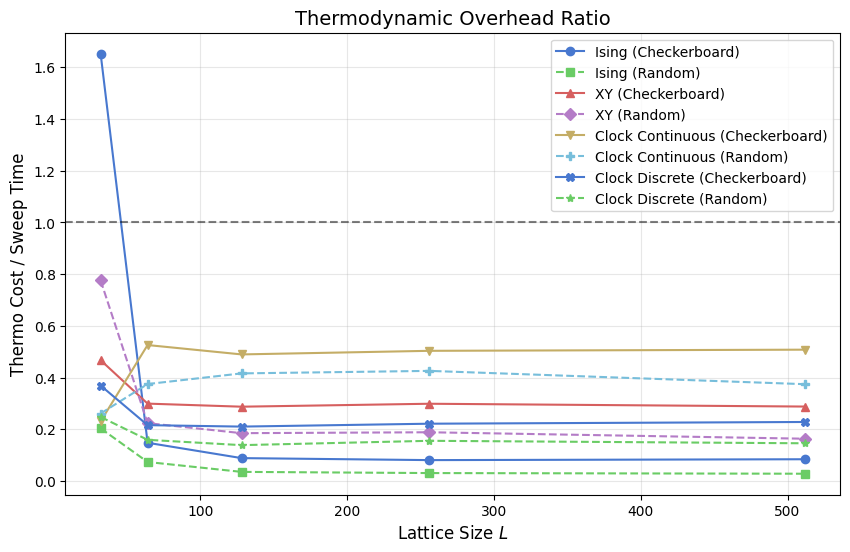

In [24]:
plt.figure(figsize=(10, 6))
for name in results:
    L_vals = sorted(results[name].keys())
    ratios = []
    for L in L_vals:
        m = results[name][L]
        sweep_ms = (1.0 / m['sps']) * 1000
        ratios.append(m['thermo_ms'] / sweep_ms)

    plt.plot(
        L_vals, ratios,
        marker=MODEL_MARKERS[name], linestyle=MODEL_LS[name], color=MODEL_COLORS[name],
        label=name,
    )

plt.title('Thermodynamic Overhead Ratio', fontsize=14)
plt.xlabel('Lattice Size $L$', fontsize=12)
plt.ylabel('Thermo Cost / Sweep Time', fontsize=12)
plt.axhline(1.0, color='black', linestyle='--', alpha=0.5)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## Scaling Exponents

The plot below fits a power law $t_{\text{sweep}} \propto N^\alpha$ to the measured sweep times via log-log linear regression, then reports $\alpha$ in the legend for each model. Ideal $O(N)$ cost gives $\alpha = 1.0$ exactly. Values above 1 indicate super-linear growth, which can arise from cache pressure at large $L$ (a full $512 \times 512$ float64 spin array occupies 2 MB for a scalar field and 4 MB for a two-component vector field, exceeding L2 cache on most CPUs). Values slightly below 1 are possible when Numba vectorizes inner loops aggressively and memory bandwidth is not yet saturated.

Comparing $\alpha$ across models separates models where cost per spin is genuinely constant from those where it drifts with size, independent of the absolute sweep rate shown in earlier plots.

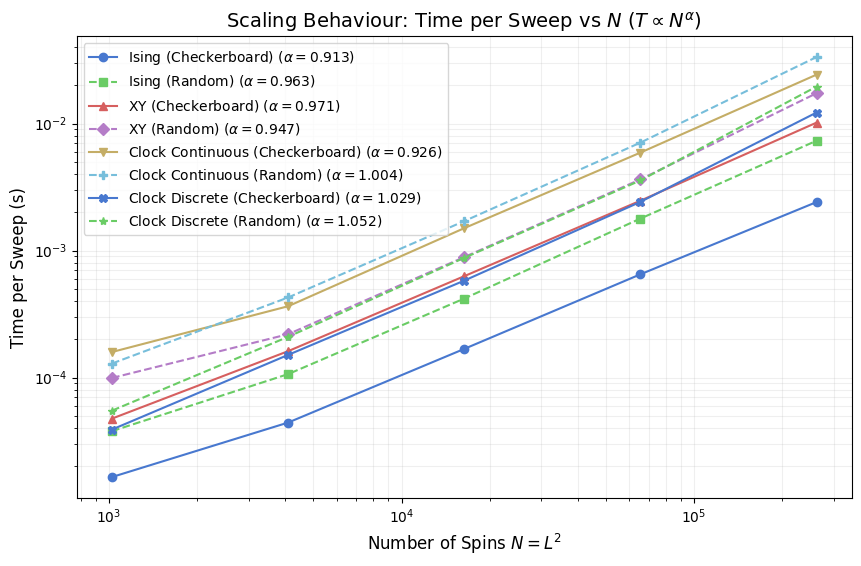

In [25]:
def analyze_scaling(sizes, results):
    plt.figure(figsize=(10, 6))
    N_vals = [L*L for L in sizes]

    for name in results:
        sps = [results[name][L]['sps'] for L in sizes]
        time_per_sweep = [1.0/s for s in sps]

        # Log-log regression for exponent extraction
        log_N = np.log(N_vals)
        log_T = np.log(time_per_sweep)
        slope, intercept, r_value, p_value, std_err = linregress(log_N, log_T)

        plt.loglog(
            N_vals, time_per_sweep,
            marker=MODEL_MARKERS[name], linestyle=MODEL_LS[name], color=MODEL_COLORS[name],
            label=rf"{name} ($\alpha={slope:.3f}$)",
        )

    plt.title(r'Scaling Behaviour: Time per Sweep vs $N$ ($T \propto N^\alpha$)', fontsize=14)
    plt.xlabel('Number of Spins $N = L^2$', fontsize=12)
    plt.ylabel('Time per Sweep (s)', fontsize=12)
    plt.grid(True, which="both", ls="-", alpha=0.2)
    plt.legend()
    plt.show()

analyze_scaling(sizes, results)

## Cost per Spin Update

Dividing sweep time by $N = L^2$ gives a size-normalized cost in nanoseconds per attempted spin flip. This collapses the $O(N)$ factor and reveals whether the per-spin cost is truly constant or carries a hidden size dependence — for instance, through rising cache-miss rates as the spin array grows beyond LLC capacity.

The Ising model sits at the bottom of this chart because each Metropolis proposal requires only a comparison of two integers and one random number; there are only six distinct $\Delta E$ values, so no per-site trig is needed. XY and the continuous clock pay a full `atan2` plus cosine evaluation per proposal. The discrete clock avoids that by looking up $\cos(2\pi\,\Delta k/q)$ in a length-$q$ table, closing roughly 60\% of the gap between continuous clock and Ising. Random-sequential update variants show slightly higher cost than checkerboard at large $L$ because random index generation adds a non-trivial per-site overhead relative to the deterministic sublattice stride.

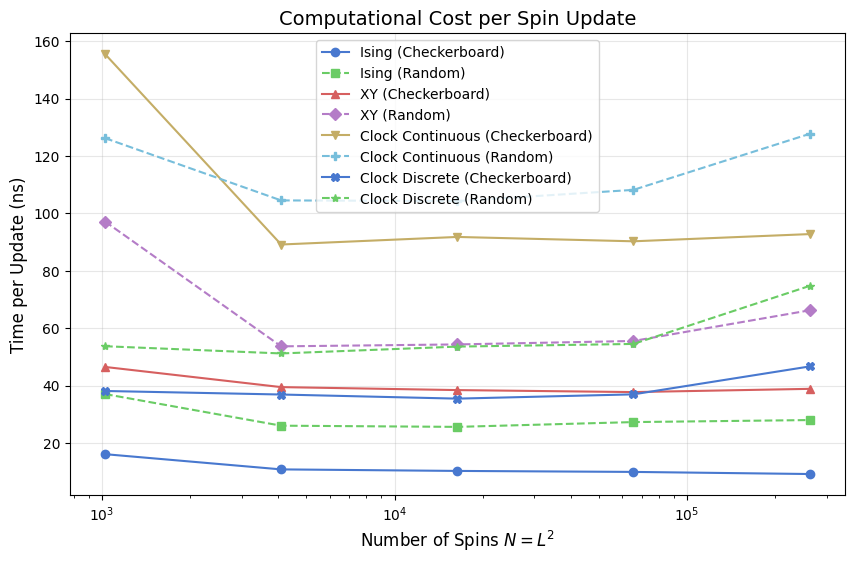

In [26]:
plt.figure(figsize=(10, 6))
for name in results:
    N_vals = [L*L for L in sizes]
    sps = [results[name][L]['sps'] for L in sizes]
    tps = [(1.0/s)/N for s, N in zip(sps, N_vals, strict=False)]
    plt.semilogx(
        N_vals, [t*1e9 for t in tps],
        marker=MODEL_MARKERS[name], linestyle=MODEL_LS[name], color=MODEL_COLORS[name],
        label=name,
    )

plt.title('Computational Cost per Spin Update', fontsize=14)
plt.xlabel('Number of Spins $N = L^2$', fontsize=12)
plt.ylabel('Time per Update (ns)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## Summary Table and Speedup Analysis

The table below records primary performance metrics at the largest lattice size ($L = 512$). We introduce the **Pure Simulation Time** metric to separate physics logic from measurement overhead. 

* **Sweeps/s**: Total throughput (lower is better for ISS, higher is better for raw speed).
* **Sweep (ms)**: Total wall time for one full lattice pass (MC step).
* **Pure (ms)**: Algorithmic time spent in the Numba update kernel, excluding observable collection.
* **Thermo (ms)**: Cost of building $M(t)$ and $E(t)$ time-series via `_get_energy()` and `_get_magnetization()`.
* **Overhead (%)**: Percentage of the total sweep budget consumed by measurements.

We quantify two major optimizations below the table: the **Checkerboard Speedup** (achieved via cache-friendly striding and SIMD vectorization) and the **Discrete Speedup** (achieved by replacing trigonometric evaluations with integer lookups).

In [27]:
L_max = sizes[-1]
print(f"Performance metrics at L = {L_max} (N = {L_max*L_max})")
print("-" * 105)
print(f"{'Model':<35} | {'Sweeps/s':>10} | {'Sweep (ms)':>10} | {'Pure (ms)':>10} | {'Thermo (ms)':>11} | {'Overhead (%)':>12}")
print("-" * 105)

for name in results:
    m = results[name][L_max]
    sweep_ms = (1.0 / m['sps']) * 1000
    pure_ms = sweep_ms - m['thermo_ms']
    overhead_pct = (m['thermo_ms'] / sweep_ms) * 100.0
    print(f"{name:<35} | {m['sps']:>10.1f} | {sweep_ms:>10.2f} | {pure_ms:>10.2f} | {m['thermo_ms']:>11.3f} | {overhead_pct:>11.1f}%")

print("\n1. Checkerboard vs Random Speedup (at constant model representation):")
for base in ['Ising', 'XY', 'Clock Continuous', 'Clock Discrete']:
    cb_key = f'{base} (Checkerboard)'
    rnd_key = f'{base} (Random)'
    cb_sps = results[cb_key][L_max]['sps']
    rnd_sps = results[rnd_key][L_max]['sps']
    speedup = cb_sps / rnd_sps
    print(f"  {base:<18}: {speedup:5.2f}x faster with Checkerboard updates")

print("\n2. Discrete vs Continuous Speedup (at constant update scheme):")
for scheme in ['Checkerboard', 'Random']:
    cont_key = f'Clock Continuous ({scheme})'
    disc_key = f'Clock Discrete ({scheme})'
    cont_sps = results[cont_key][L_max]['sps']
    disc_sps = results[disc_key][L_max]['sps']
    speedup = disc_sps / cont_sps
    print(f"  {scheme:<12}: {speedup:5.2f}x faster with Discrete representation")


Performance metrics at L = 512 (N = 262144)
---------------------------------------------------------------------------------------------------------
Model                               |   Sweeps/s | Sweep (ms) |  Pure (ms) | Thermo (ms) | Overhead (%)
---------------------------------------------------------------------------------------------------------
Ising (Checkerboard)                |      414.3 |       2.41 |       2.21 |       0.202 |         8.4%
Ising (Random)                      |      136.2 |       7.34 |       7.14 |       0.205 |         2.8%
XY (Checkerboard)                   |       98.1 |      10.19 |       7.26 |       2.932 |        28.8%
XY (Random)                         |       57.6 |      17.36 |      14.53 |       2.835 |        16.3%
Clock Continuous (Checkerboard)     |       41.1 |      24.32 |      11.97 |      12.351 |        50.8%
Clock Continuous (Random)           |       29.9 |      33.47 |      20.95 |      12.528 |        37.4%
Clock Discrete (

The table above reports performance at the largest lattice size and separates total sweep time from measurement overhead. Pure simulation time isolates update-kernel cost, while thermodynamic time captures per-step collection of energy and magnetization during measurement windows.

Use the checkerboard-versus-random speedup lines to assess update-order efficiency at fixed spin representation, and use the discrete-versus-continuous clock comparison to quantify the gain from lookup-table arithmetic over per-site trigonometric evaluation.

---
### Bibliography

All references cited above are open-access or from reputable sources:

1. Onsager, L. (1944). Crystal Statistics. I. A Two-Dimensional Model with an Order-Disorder Transition. Physical Review, 65(3-4), 117–149. https://journals.aps.org/pr/abstract/10.1103/PhysRev.65.117
2. Kosterlitz, J. M., & Thouless, D. J. (1973). Ordering, metastability and phase transitions in two-dimensional systems. Journal of Physics C: Solid State Physics, 6(7), 1181–1203. https://iopscience.iop.org/article/10.1088/0022-3719/6/7/010
3. Lapilli, J., Pfeifer, P., & Wexler, C. (2006). Universality away from critical points in two-dimensional phase transitions. Physical Review Letters, 96(14), 140603. https://journals.aps.org/prl/abstract/10.1103/PhysRevLett.96.140603
4. Hastings, W. K. (1970). Monte Carlo sampling methods using Markov chains and their applications. Biometrika, 57(1), 97–109. https://academic.oup.com/biomet/article/57/1/97/252073
5. Numba JIT and parallelization: https://numba.readthedocs.io/en/stable/user/parallel.html
6. [Ising model on Wikipedia](https://en.wikipedia.org/wiki/Ising_model)
7. [XY model on Wikipedia](https://en.wikipedia.org/wiki/XY_model)
8. [Clock model on Wikipedia](https://en.wikipedia.org/wiki/Potts_model#Vector_Potts_model)
9. [Metropolis–Hastings algorithm on Wikipedia](https://en.wikipedia.org/wiki/Metropolis%E2%80%93Hastings_algorithm)


G(r) Cost:   0%|          | 0/8 [00:00<?, ?it/s]

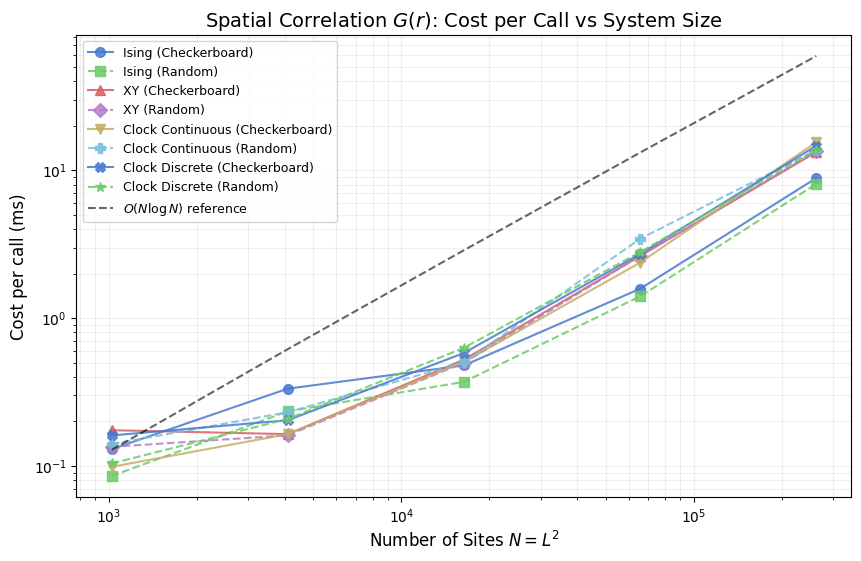

G(r) cost per call at L=512 (N=262144)
Model                                 ms/call  representation
------------------------------------------------------------------------
Ising (Checkerboard)                     8.85  scalar, 1 FFT
Ising (Random)                           8.09  scalar, 1 FFT
XY (Checkerboard)                       13.27  2-component float, 2 FFTs
XY (Random)                             13.45  2-component float, 2 FFTs
Clock Continuous (Checkerboard)         15.48  2-component float, 2 FFTs
Clock Continuous (Random)               13.67  2-component float, 2 FFTs
Clock Discrete (Checkerboard)           14.63  int -> float + 2 FFTs
Clock Discrete (Random)                 13.76  int -> float + 2 FFTs

Tier means:
  Ising (scalar, 1 FFT)                8.47 ms  (reference)
  XY / Clock Continuous (2 FFTs)      13.97 ms  (1.65x Ising)
  Clock Discrete (convert + 2 FFTs)   14.20 ms  (1.02x XY tier,  1.68x Ising)


In [28]:
CORR_ITERS = 50  # timed calls per (model, size)

if _loaded_from_npz:
    # G(r) cost data is already in results; no re-timing needed.
    corr_results = {
        name: {L: results[name][L]['corr_ms'] for L in sizes}
        for name in results
    }
else:
    corr_results = {}
    for corr_name, corr_constructor in tqdm(model_configs, desc='G(r) Cost'):
        corr_results[corr_name] = {}
        for L in sizes:
            corr_sim = corr_constructor(L)
            # Two warm-up calls; JIT is already compiled from the main benchmark warm-up.
            corr_sim._calculate_correlation_function()
            corr_sim._calculate_correlation_function()
            start = time.perf_counter()
            for _ in range(CORR_ITERS):
                corr_sim._calculate_correlation_function()
            corr_results[corr_name][L] = (time.perf_counter() - start) / CORR_ITERS * 1000

# N log N reference line anchored to the mean cost at L=32
N_ref = np.array([L * L for L in sizes], dtype=float)
mean_at_L0 = float(np.mean([corr_results[n][sizes[0]] for n in corr_results]))
N0 = float(sizes[0] ** 2)
nlogn_ref = mean_at_L0 * (N_ref * np.log2(N_ref)) / (N0 * np.log2(N0))

plt.figure(figsize=(10, 6))
for corr_name in corr_results:
    L_vals = sorted(corr_results[corr_name].keys())
    N_vals = [L * L for L in L_vals]
    cost_vals = [corr_results[corr_name][L] for L in L_vals]
    plt.loglog(
        N_vals, cost_vals,
        marker=MODEL_MARKERS[corr_name], linestyle=MODEL_LS[corr_name],
        color=MODEL_COLORS[corr_name], label=corr_name, markersize=7, alpha=0.85,
    )

plt.loglog(N_ref, nlogn_ref, 'k--', linewidth=1.5, alpha=0.6, label=r'$O(N \log N)$ reference')
plt.title('Spatial Correlation $G(r)$: Cost per Call vs System Size', fontsize=14)
plt.xlabel('Number of Sites $N = L^2$', fontsize=12)
plt.ylabel('Cost per call (ms)', fontsize=12)
plt.grid(True, which='both', ls='-', alpha=0.2)
plt.legend(fontsize=9)
plt.show()

# --- Cost table grouped by spin-representation tier --------------------------
L_show = sizes[-1]
_tier = {
    'Ising (Checkerboard)':            'scalar, 1 FFT',
    'Ising (Random)':                  'scalar, 1 FFT',
    'XY (Checkerboard)':               '2-component float, 2 FFTs',
    'XY (Random)':                     '2-component float, 2 FFTs',
    'Clock Continuous (Checkerboard)': '2-component float, 2 FFTs',
    'Clock Continuous (Random)':       '2-component float, 2 FFTs',
    'Clock Discrete (Checkerboard)':   'int -> float + 2 FFTs',
    'Clock Discrete (Random)':         'int -> float + 2 FFTs',
}

print(f"G(r) cost per call at L={L_show} (N={L_show**2})")
print(f"{'Model':<35} {'ms/call':>9}  representation")
print("-" * 72)
for corr_name in corr_results:
    ms = corr_results[corr_name][L_show]
    print(f"{corr_name:<35} {ms:>9.2f}  {_tier[corr_name]}")

# Tier averages and cross-tier ratios
ising_ms = np.mean([corr_results[k][L_show] for k in ('Ising (Checkerboard)', 'Ising (Random)')])
xy_ms    = np.mean([corr_results[k][L_show] for k in (
    'XY (Checkerboard)', 'XY (Random)',
    'Clock Continuous (Checkerboard)', 'Clock Continuous (Random)',
)])
disc_ms  = np.mean([corr_results[k][L_show] for k in (
    'Clock Discrete (Checkerboard)', 'Clock Discrete (Random)',
)])

print()
print("Tier means:")
print(f"  Ising (scalar, 1 FFT)              {ising_ms:6.2f} ms  (reference)")
print(f"  XY / Clock Continuous (2 FFTs)     {xy_ms:6.2f} ms  ({xy_ms/ising_ms:.2f}x Ising)")
print(
    f"  Clock Discrete (convert + 2 FFTs)  {disc_ms:6.2f} ms  "
    f"({disc_ms/xy_ms:.2f}x XY tier,  {disc_ms/ising_ms:.2f}x Ising)"
)

## Autocorrelation Time and Sampling Efficiency

The spatial correlation function $G(r)$ measures equal-time correlations between sites separated by distance $r$. Its MC-time counterpart is the integrated autocorrelation time $\tau_{\text{int}}$, measured in sweeps: two magnetization samples separated by fewer than $\tau_{\text{int}}$ sweeps are statistically dependent and do not independently reduce the error on ensemble averages.

Raw throughput in sweeps per second is therefore not the complete figure of merit for equilibrium sampling. The relevant rate is the independent samples per second, $\text{ISS} = \text{sweeps/s} \div \tau_{\text{int}}$. A model with twice the throughput but four times the autocorrelation time explores configuration space at half the effective rate.

$\tau_{\text{int}}$ is estimated via an FFT-based autocorrelation estimator with the Madras\u2013Sokal automatic windowing rule, which cuts integration at lag $W = 6\,\tau_{\text{int}}$ to suppress noise accumulation at large lags. Each model is run for a $500$-sweep burn-in then a $2000$-sweep magnetization series at $L=64$; this is long enough for well-separated phases but may under-resolve $\tau_{\text{int}}$ right at a critical point where the true value diverges with $L$. In that case the reported number is a lower bound.

In [29]:
TAU_L      = 64    # lattice size for autocorrelation measurement
TAU_BURNIN = 500   # equilibration steps before the measurement window
TAU_SWEEPS = 2000  # magnetization time-series length

tau_results = {}

for tau_name, tau_constructor in tqdm(model_configs, desc='Autocorrelation'):
    tau_sim = tau_constructor(TAU_L)
    tau_sim.equilibrate(n_steps=TAU_BURNIN)
    tau_mags, _ = tau_sim.run(n_steps=TAU_SWEEPS)
    try:
        _, tau = calculate_autocorr(time_series=np.array(tau_mags))
    except ValueError:
        # Zero-variance series (fully ordered phase): tau_int is undefined.
        tau = float('nan')
    tau_sps = results[tau_name][TAU_L]['sps']
    tau_iss = tau_sps / tau if np.isfinite(tau) and tau > 0 else float('nan')
    tau_results[tau_name] = {'tau_int': tau, 'iss': tau_iss}

print(f"MC autocorrelation at L={TAU_L}  ({TAU_SWEEPS}-sweep series, {TAU_BURNIN}-step burn-in)")
print("-" * 72)
print(f"{'Model':<35} {'tau_int (sweeps)':>18} {'ISS (samples/s)':>18}")
print("-" * 72)
for tau_name, d in tau_results.items():
    tau_str = f"{d['tau_int']:>18.1f}" if np.isfinite(d['tau_int']) else f"{'N/A':>18}"
    iss_str = f"{d['iss']:>18.1f}"     if np.isfinite(d['iss'])     else f"{'N/A':>18}"
    print(f"{tau_name:<35}{tau_str}{iss_str}")

Autocorrelation:   0%|          | 0/8 [00:00<?, ?it/s]

MC autocorrelation at L=64  (2000-sweep series, 500-step burn-in)
------------------------------------------------------------------------
Model                                 tau_int (sweeps)    ISS (samples/s)
------------------------------------------------------------------------
Ising (Checkerboard)                            153.1             147.4
Ising (Random)                                  269.1              34.8
XY (Checkerboard)                               145.6              42.5
XY (Random)                                     296.1              15.4
Clock Continuous (Checkerboard)                  97.9              28.0
Clock Continuous (Random)                       139.6              16.7
Clock Discrete (Checkerboard)                   313.7              21.1
Clock Discrete (Random)                          75.2              63.4


The table above reports raw numbers. The two panels below plot the same data as horizontal bar charts, making it straightforward to rank models by decorrelation speed and by effective sampling rate in a single glance.

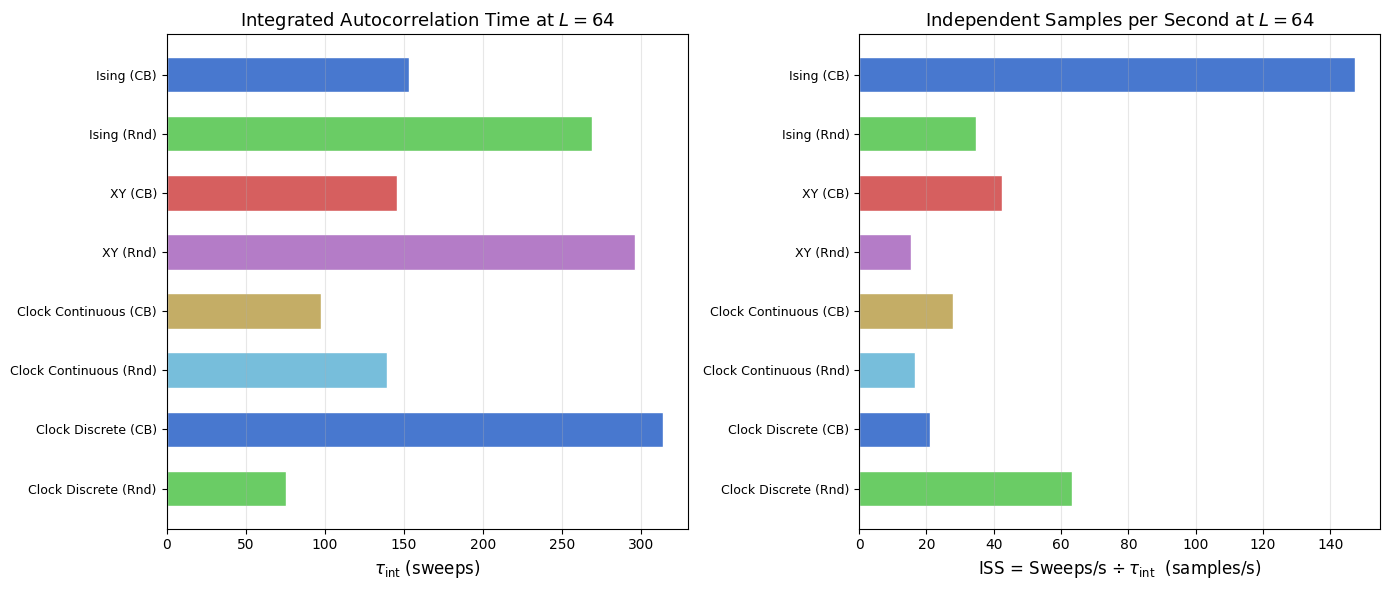

In [30]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

tau_names  = list(tau_results.keys())
tau_colors = [MODEL_COLORS[n] for n in tau_names]
y_pos      = np.arange(len(tau_names))
short_labels = [
    n.replace(' (Checkerboard)', ' (CB)').replace(' (Random)', ' (Rnd)')
    for n in tau_names
]

tau_vals = [tau_results[n]['tau_int'] for n in tau_names]
iss_vals  = [tau_results[n]['iss']     for n in tau_names]

ax1.barh(y_pos, tau_vals, color=tau_colors, edgecolor='white', height=0.6)
ax1.set_yticks(y_pos)
ax1.set_yticklabels(short_labels, fontsize=9)
ax1.set_xlabel(r'$\tau_\mathrm{int}$ (sweeps)', fontsize=12)
ax1.set_title(rf'Integrated Autocorrelation Time at $L={TAU_L}$', fontsize=13)
ax1.invert_yaxis()
ax1.grid(True, alpha=0.3, axis='x')

ax2.barh(y_pos, iss_vals, color=tau_colors, edgecolor='white', height=0.6)
ax2.set_yticks(y_pos)
ax2.set_yticklabels(short_labels, fontsize=9)
ax2.set_xlabel(r'ISS = Sweeps/s $\div\,\tau_\mathrm{int}$  (samples/s)', fontsize=12)
ax2.set_title(rf'Independent Samples per Second at $L={TAU_L}$', fontsize=13)
ax2.invert_yaxis()
ax2.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

## Hardware Scaling & Multi-core Performance

This section probes the limits of VibeSpin's architecture on modern CPU hierarchies. We examine the **nanoseconds per spin update** to detect cache-tier transitions and benchmark **Topological Observables** which involve non-local plaquette traversals. Finally, we quantify the gain from **Numba Multi-threading** (`parallel=True`) which utilizes multiple cores for sublattice updates.

### Efficiency: Nanoseconds per site update

Throughput (sweeps/s) decreases as $N$ increases, but the cost per spin update should ideally remain constant. The plot below shows this metric for all models. Upward drifts at large $L$ indicate hardware bottlenecks (cache misses or memory bandwidth saturation), while downward drifts suggest Numba's vectorization becoming more effective.

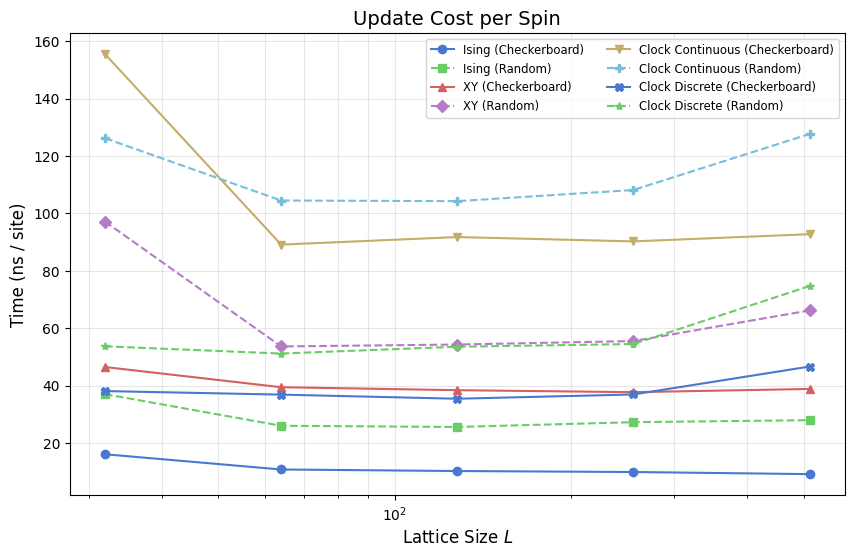

In [31]:
plt.figure(figsize=(10, 6))
for name in results:
    L_vals = sorted(results[name].keys())
    ns_per_site = []
    for L in L_vals:
        t_sweep = 1.0 / results[name][L]['sps']
        ns_per_site.append((t_sweep / (L*L)) * 1e9)

    plt.semilogx(L_vals, ns_per_site, marker=MODEL_MARKERS[name], linestyle=MODEL_LS[name],
                 color=MODEL_COLORS[name], label=name)

plt.title('Update Cost per Spin', fontsize=14)
plt.xlabel('Lattice Size $L$', fontsize=12)
plt.ylabel('Time (ns / site)', fontsize=12)
plt.grid(True, which='both', alpha=0.3)
plt.legend(fontsize='small', ncol=2)
plt.show()

### Topological and Vector Analysis Cost

Physical studies of the XY and Clock models often depend on detecting topological defects (vortices) or calculating the helicity modulus (phase-twist response). These operations involve multiple trigonometric sums and phase-wrapping operations per site, making them significantly costlier than standard thermodynamic measurements.

Topological Analysis:   0%|          | 0/5 [00:00<?, ?it/s]

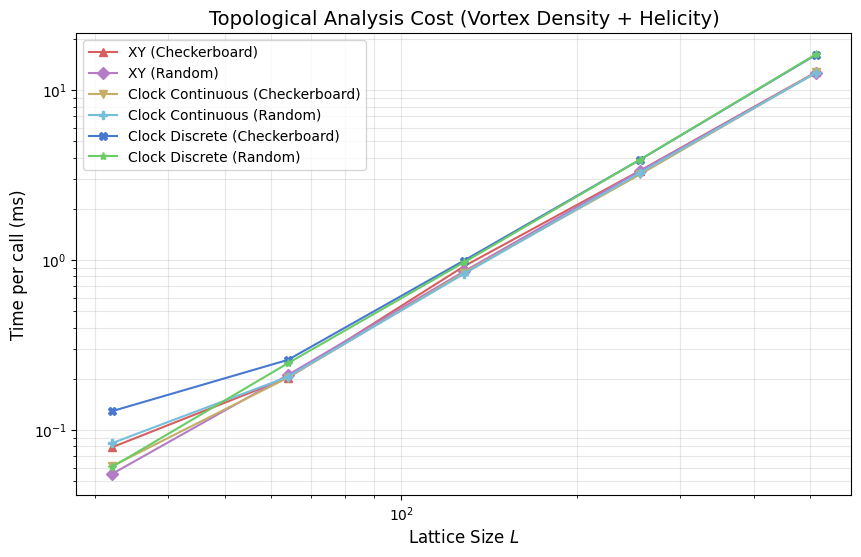

In [32]:
topo_results = {name: {} for name, _ in model_configs if 'Ising' not in name}

if _loaded_from_npz:
    # Topological cost data is already in results as separate vden_ms and heli_ms
    # components, matching what this section measures: _get_vortex_density() +
    # _get_helicity_data() timed together per call.
    for name in topo_results:
        for L in sizes:
            r = results[name][L]
            topo_results[name][L] = r['vden_ms'] + r['heli_ms']
else:
    for L in tqdm(sizes, desc='Topological Analysis'):
        for name, constructor in model_configs:
            if 'Ising' in name: continue
            sim = constructor(L)
            # Warm-up
            if hasattr(sim, '_calculate_vorticity'): sim._calculate_vorticity()
            if hasattr(sim, '_get_helicity_data'): sim._get_helicity_data()

            start = time.perf_counter()
            for _ in range(ANALYSIS_ITERS):
                v_dens = sim._get_vortex_density()
                heli = sim._get_helicity_data()
            topo_ms = (time.perf_counter() - start) / ANALYSIS_ITERS * 1000
            topo_results[name][L] = topo_ms

plt.figure(figsize=(10, 6))
for name in topo_results:
    L_vals = sorted(topo_results[name].keys())
    plt.loglog(L_vals, [topo_results[name][L] for L in L_vals],
               marker=MODEL_MARKERS[name], color=MODEL_COLORS[name], label=name)

plt.title('Topological Analysis Cost (Vortex Density + Helicity)', fontsize=14)
plt.xlabel('Lattice Size $L$', fontsize=12)
plt.ylabel('Time per call (ms)', fontsize=12)
plt.grid(True, which='both', alpha=0.3)
plt.legend()
plt.show()

This section times non-local observables for XY and clock-family models, focusing on vortex-density and helicity related computations that require plaquette traversals and additional phase operations.

Compared with per-step thermodynamic collection, these routines are analysis-heavy and are typically evaluated intermittently rather than every sweep. The plot above should be read as an analysis budget curve versus lattice size, not as an update-kernel throughput metric.

### Parallel Scaling Benchmark

Checkerboard updates partition the lattice into two independent sublattices, one updated per half-step. Because sites within each sublattice do not share nearest neighbours, all updates in a sublattice pass are independent and can execute concurrently without read-write conflicts. VibeSpin exposes this via `parallel=True`, which directs Numba to spawn threads across the sublattice using `prange`.

The code below measures Ising checkerboard throughput at $L \in \{128, 256, 512, 1024\}$ in both serial and parallel modes. The left panel shows absolute throughput; the right panel shows the speedup ratio, revealing the crossover from overhead-bound to compute-bound as $L$ grows.

Parallel Benchmark:   0%|          | 0/4 [00:00<?, ?it/s]

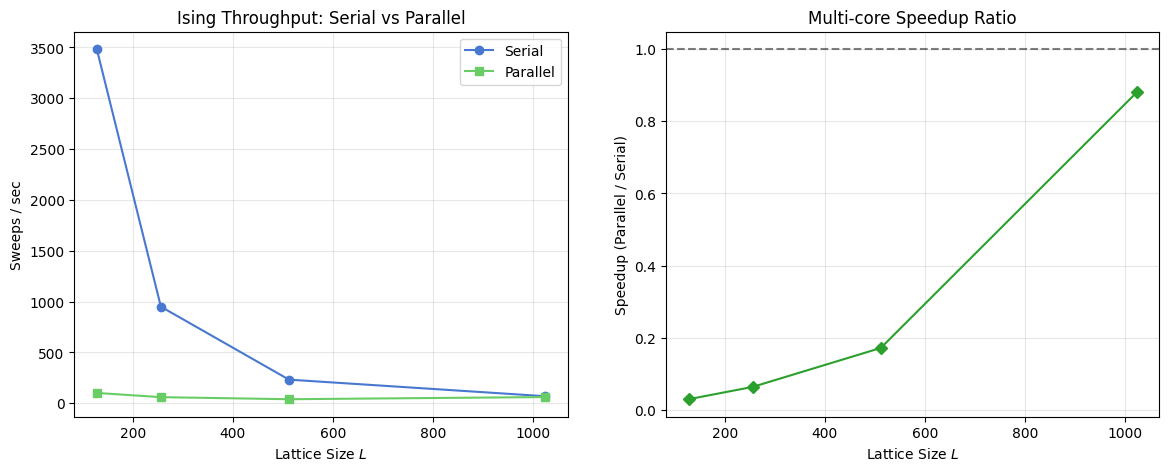

In [33]:
p_sizes = [128, 256, 512, 1024]
p_results = {'Serial': [], 'Parallel': []}

for L in tqdm(p_sizes, desc='Parallel Benchmark'):
    # Serial
    s_sim = IsingSimulation(size=L, temp=2.269, update='checkerboard', parallel=False)
    s_sim.step() # Warm-up
    start = time.perf_counter()
    for _ in range(50): s_sim.step()
    p_results['Serial'].append(50 / (time.perf_counter() - start))

    # Parallel
    p_sim = IsingSimulation(size=L, temp=2.269, update='checkerboard', parallel=True)
    p_sim.step() # Warm-up
    start = time.perf_counter()
    for _ in range(50): p_sim.step()
    p_results['Parallel'].append(50 / (time.perf_counter() - start))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(p_sizes, p_results['Serial'], 'o-', label='Serial')
ax1.plot(p_sizes, p_results['Parallel'], 's-', label='Parallel')
ax1.set_title('Ising Throughput: Serial vs Parallel')
ax1.set_xlabel('Lattice Size $L$')
ax1.set_ylabel('Sweeps / sec')
ax1.legend()
ax1.grid(True, alpha=0.3)

speedup = [p/s for p, s in zip(p_results['Parallel'], p_results['Serial'])]
ax2.plot(p_sizes, speedup, 'D-', color='tab:green')
ax2.axhline(1.0, color='black', linestyle='--', alpha=0.5)
ax2.set_title('Multi-core Speedup Ratio')
ax2.set_xlabel('Lattice Size $L$')
ax2.set_ylabel('Speedup (Parallel / Serial)')
ax2.grid(True, alpha=0.3)
plt.show()

### Parallel Scaling Benchmark
This section benchmarks checkerboard Metropolis throughput in serial and parallel modes for the Ising model across increasing lattice sizes.
The code cell above computes sweeps per second and plots both absolute throughput and the parallel speedup ratio.
Interpret the right panel as a hardware-plus-size dependent crossover: small lattices can be overhead bound, while larger lattices benefit more from multithreading.

## Comprehensive Performance Dashboard

The six-panel figure below assembles the main performance dimensions into a single view. From top-left to bottom-right: update throughput (sweeps/s), per-spin update cost (ns/site), $G(r)$ analysis time, topological analysis time, thermodynamic collection cost, and the per-step overhead ratio. All panels share the same lattice sizes, model colours, and markers, so cross-panel comparisons are direct.

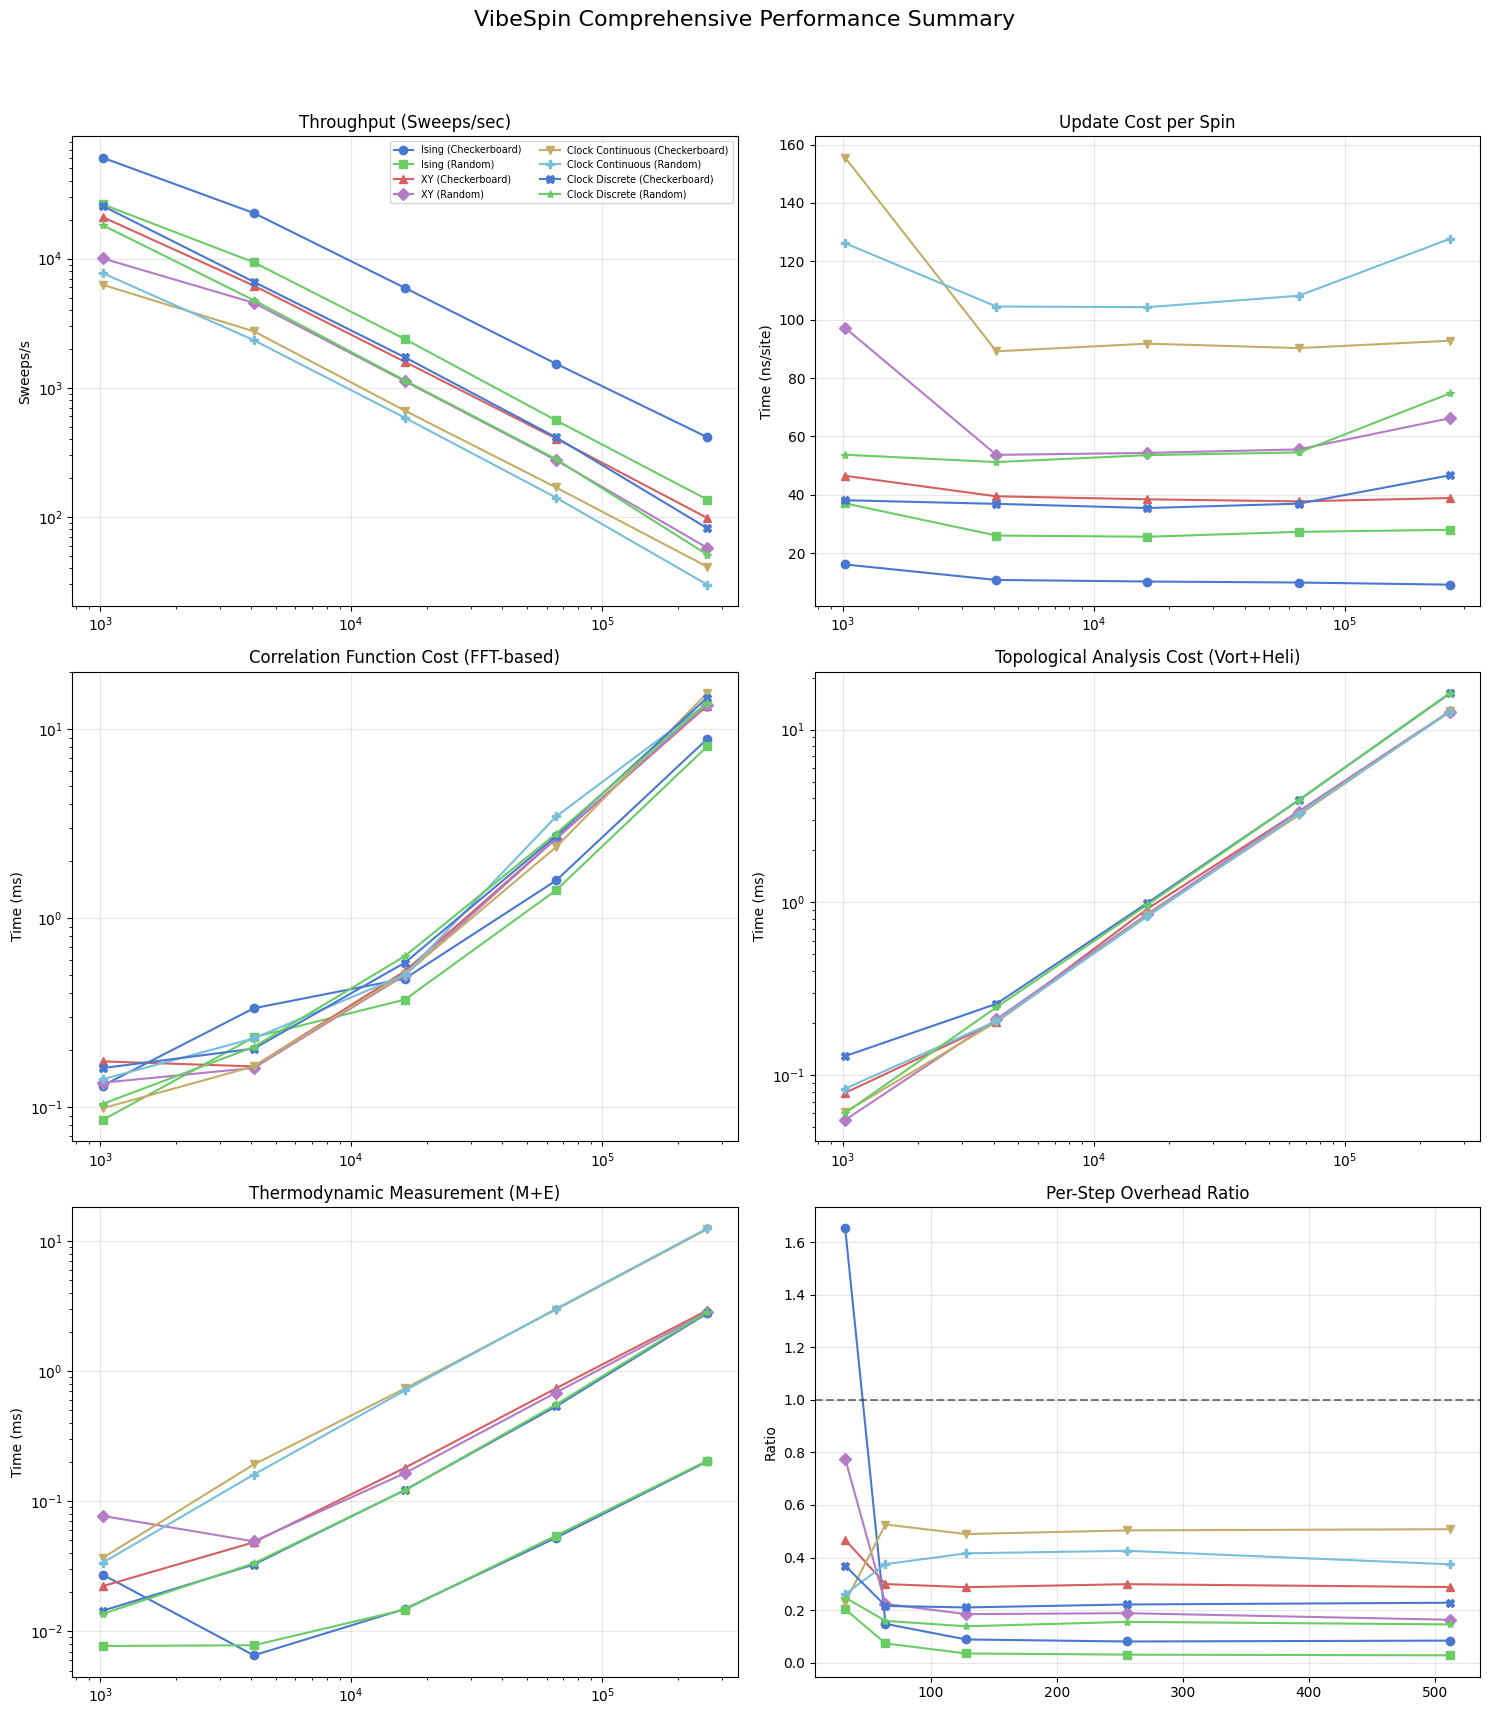

In [34]:
fig, axes = plt.subplots(3, 2, figsize=(15, 18))
fig.suptitle('VibeSpin Comprehensive Performance Summary', fontsize=16)
ax1, ax2, ax3, ax4, ax5, ax6 = axes.flatten()

for name in results:
    L_vals = sorted(results[name].keys())
    N_vals = [L*L for L in L_vals]

    # 1. Throughput
    ax1.loglog(N_vals, [results[name][L]['sps'] for L in L_vals], marker=MODEL_MARKERS[name], color=MODEL_COLORS[name], label=name)

    # 2. ns per site
    ns_site = [( (1.0/results[name][L]['sps']) / (L*L) ) * 1e9 for L in L_vals]
    ax2.semilogx(N_vals, ns_site, marker=MODEL_MARKERS[name], color=MODEL_COLORS[name])

    # 3. Correlation function G(r)
    if 'corr_results' in locals() and name in corr_results:
        c_L = sorted(corr_results[name].keys())
        ax3.loglog([l*l for l in c_L], [corr_results[name][l] for l in c_L], marker=MODEL_MARKERS[name], color=MODEL_COLORS[name])

    # 4. Topological Analysis
    if 'topo_results' in locals() and name in topo_results:
        t_L = sorted(topo_results[name].keys())
        ax4.loglog([l*l for l in t_L], [topo_results[name][l] for l in t_L], marker=MODEL_MARKERS[name], color=MODEL_COLORS[name])

    # 5. Thermodynamic Measurement
    ax5.loglog(N_vals, [results[name][L]['thermo_ms'] for L in L_vals], marker=MODEL_MARKERS[name], color=MODEL_COLORS[name])

    # 6. Per-Step Overhead Ratio
    overheads = [results[name][L]['thermo_ms'] / (1000.0/results[name][L]['sps']) for L in L_vals]
    ax6.plot(L_vals, overheads, marker=MODEL_MARKERS[name], color=MODEL_COLORS[name])

ax1.set_title('Throughput (Sweeps/sec)'); ax1.set_ylabel('Sweeps/s'); ax1.legend(fontsize='x-small', ncol=2)
ax2.set_title('Update Cost per Spin'); ax2.set_ylabel('Time (ns/site)')
ax3.set_title('Correlation Function Cost (FFT-based)'); ax3.set_ylabel('Time (ms)')
ax4.set_title('Topological Analysis Cost (Vort+Heli)'); ax4.set_ylabel('Time (ms)')
ax5.set_title('Thermodynamic Measurement (M+E)'); ax5.set_ylabel('Time (ms)')
ax6.set_title('Per-Step Overhead Ratio'); ax6.set_ylabel('Ratio'); ax6.axhline(1.0, color='black', ls='--', alpha=0.5)

for ax in axes.flatten(): ax.grid(True, alpha=0.3)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

The final panelized figure aggregates update throughput, per-spin update cost, observable overheads, and analysis-time scaling across models.
Use this summary to compare asymptotic trends rather than single-point values, since warm-up costs and finite-size effects can distort small-system timings.
In equilibrium workflows near criticality, combine these timing curves with autocorrelation behavior to estimate effective independent-sample throughput.